# OCR Noise Robustness in Document Image Classification using Deep Learning

## Machine Learning Project

---

### Team Members

- Gireesh Chowdary Tripuraneni
- Gurudeep Ravilla
- Prudhvi sai

---

## Abstract

Document image classification is an important task in intelligent document management systems. Large organizations process thousands of scanned documents every day, including invoices, forms, letters, reports, emails, and scientific publications. Automatic document classification improves indexing, searching, retrieval, and workflow automation.

Although modern deep learning models achieve excellent classification accuracy on clean datasets, real-world document images frequently contain scanning artifacts such as blur, Gaussian noise, rotation, compression, and salt-and-pepper noise. These degradations negatively affect both document classification and Optical Character Recognition (OCR).

This project develops a complete document understanding pipeline using a pretrained **ResNet-18 Convolutional Neural Network** for document classification and **EasyOCR** fr text extraction. Different image degradations are simulated to evaluate the robustness of the classification model and OCR system under realistic conditions.

The notebook presents an end-to-end workflow including:

- Dataset preparation
- Image preprocessing
- Deep learning model training
- Document classification
- OCR text extraction
- Noise simulation
- Robustness evaluation
- Performance visualization
- Experimental analysis

The implementation is fully self-contained and reproducible using only the dataset.

## Step 1: Mount Google Drive

In this step, we connect Google Colab with Google Drive.

**Why?**
- Our dataset and trained model are stored in Google Drive.
- Mounting the drive allows Colab to access these files.

**Output**
Google Drive becomes available inside `/content/drive`.

In [7]:
import os
import shutil

if os.path.exists('/content/drive'):
    shutil.rmtree('/content/drive')

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Define Dataset Location

After mounting Google Drive, we specify the location of the OCR Robustness project.

**Purpose**
- Store the dataset path in a variable.
- Import the required Python libraries.

This makes the code reusable without changing paths multiple times.

In [ ]:


from google.colab import drive
drive.mount('/content/drive')

import os

# Path to your dataset
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/OCR_Robustness_Project/data"

print("Path exists:", os.path.exists(DATASET_PATH))
print("Folders:", os.listdir(DATASET_PATH))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Path exists: True
Folders: ['specification', 'scientific publication', 'resume', 'questionnaire', 'scientific report', 'news article', 'presentation', 'memo', 'letter', 'invoice', 'email', 'budget', 'form', 'advertisement', 'handwritten', 'file folder']


## Step 3: Verify Dataset

Before training or testing, we ensure that the dataset exists.

The code:
- Checks whether the dataset folder is available.
- Displays its contents.

This helps detect path errors before execution.

In [10]:
import os

DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/OCR_Robustness_Project/data"

print("Exists:", os.path.exists(DATASET_PATH))
print("Contents:", os.listdir(DATASET_PATH))

Exists: True
Contents: ['specification', 'scientific publication', 'resume', 'questionnaire', 'scientific report', 'news article', 'presentation', 'memo', 'letter', 'invoice', 'email', 'budget', 'form', 'advertisement', 'handwritten', 'file folder']


## Step 4: Inspect Dataset Structure

This cell performs an additional verification.

It shows:
- Whether the dataset exists.
- Number of folders.
- Names of document categories.

This confirms that all classes are correctly loaded.

In [11]:
import os

print(os.path.exists(DATASET_PATH))
print(len(os.listdir(DATASET_PATH)))
print(os.listdir(DATASET_PATH))

True
16
['specification', 'scientific publication', 'resume', 'questionnaire', 'scientific report', 'news article', 'presentation', 'memo', 'letter', 'invoice', 'email', 'budget', 'form', 'advertisement', 'handwritten', 'file folder']


# Problem Statement and Objectives

## Problem Statement

Automatic document classification has become increasingly important due to the rapid growth of digitized documents in business, healthcare, education, and government organizations.

Most document classification systems are trained using clean scanned images. However, practical document images often contain degradations caused by scanning devices, camera capture, poor lighting conditions, motion blur, image compression, and document aging.

These degradations not only reduce classification accuracy but also decrease OCR performance, making reliable document understanding more challenging.

This project investigates the robustness of a deep learning document classification system under multiple image degradation conditions.

---

## Objectives

The primary objectives of this project are:

- Prepare the RVL-CDIP document dataset
- Preprocess document images for deep learning
- Train a ResNet-18 document classification model
- Perform document classification
- Extract text using EasyOCR
- Simulate multiple image degradation techniques
- Evaluate robustness under noisy conditions
- Compare OCR performance across noise types
- Generate performance metrics and visualizations

---

## Workflow

RVL-CDIP Dataset

↓

Image Preprocessing

↓

ResNet-18 Training

↓

Document Classification

↓

EasyOCR

↓

Noise Simulation

↓

Robustness Evaluation

↓

Performance Visualization

↓

Discussion & Conclusion

## Step 5: Create Custom Dataset

PyTorch requires data in a specific format.

This custom Dataset class:
- Reads document images.
- Assigns labels.
- Returns image-label pairs.

This allows the model to process the dataset efficiently.

In [ ]:
import os
from torch.utils.data import Dataset
from PIL import Image



class RVLCDIPDataset(Dataset):

    def __init__(self, root_dir):

        self.root_dir = root_dir

        self.classes = sorted([

            folder

            for folder in os.listdir(root_dir)

            if os.path.isdir(

                os.path.join(root_dir, folder)

            )

        ])

        self.class_to_idx = {

            cls: idx

            for idx, cls in enumerate(self.classes)

        }

        self.samples = []

        for cls in self.classes:

            class_folder = os.path.join(

                root_dir,

                cls

            )

            for file in os.listdir(class_folder):

                if file.lower().endswith(

                    (".tif", ".tiff")

                ):

                    self.samples.append(

                        (

                            os.path.join(

                                class_folder,

                                file

                            ),

                            self.class_to_idx[cls]

                        )

                    )

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, index):

        image_path, label = self.samples[index]

        image = Image.open(

            image_path

        ).convert("RGB")

        return image, label


DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/OCR_Robustness_Project/data"
dataset = RVLCDIPDataset(DATASET_PATH)

classes = dataset.classes

print("="*70)
print("DATASET LOADED")
print("="*70)

print(f"Classes : {len(classes)}")
print(f"Images  : {len(dataset)}")

DATASET LOADED
Classes : 16
Images  : 47996


## Step 6: Image Preprocessing

Deep learning models require images of identical size.

This step:
- Resizes images.
- Converts images into tensors.
- Normalizes pixel values.

These transformations improve model performance and training stability.

In [ ]:
import torchvision.transforms as transforms

# Define IMAGE_SIZE if not already defined globally or in an earlier cell
IMAGE_SIZE = 224 # Common size for many models like ResNet



test_transform = transforms.Compose([

    transforms.Resize(

        (IMAGE_SIZE, IMAGE_SIZE)

    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],

        std=[0.229,0.224,0.225]

    )

])

print("Transform loaded successfully.")

Transform loaded successfully.


## Step 7: Dataset Analysis

Before training, we analyze the dataset.

This cell:
- Counts images in each class.
- Generates graphs.
- Checks class balance.

Understanding the dataset helps identify possible bias.

,Document Class,Images
0,advertisement,2994
1,budget,3002
2,email,2993
3,file folder,3003
4,form,2994
5,handwritten,3005
6,invoice,2992
7,letter,3015
8,memo,2996
9,news article,3001


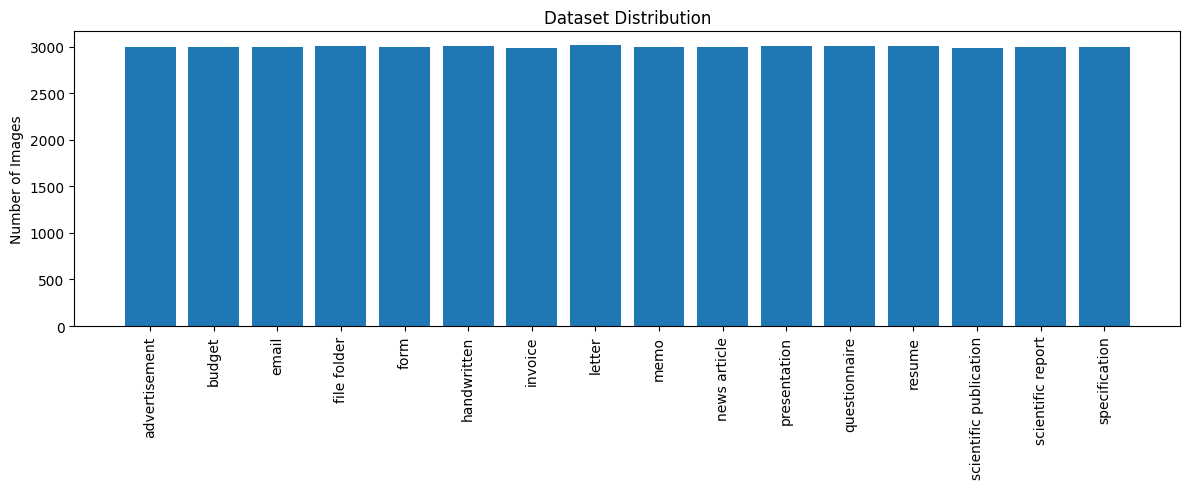

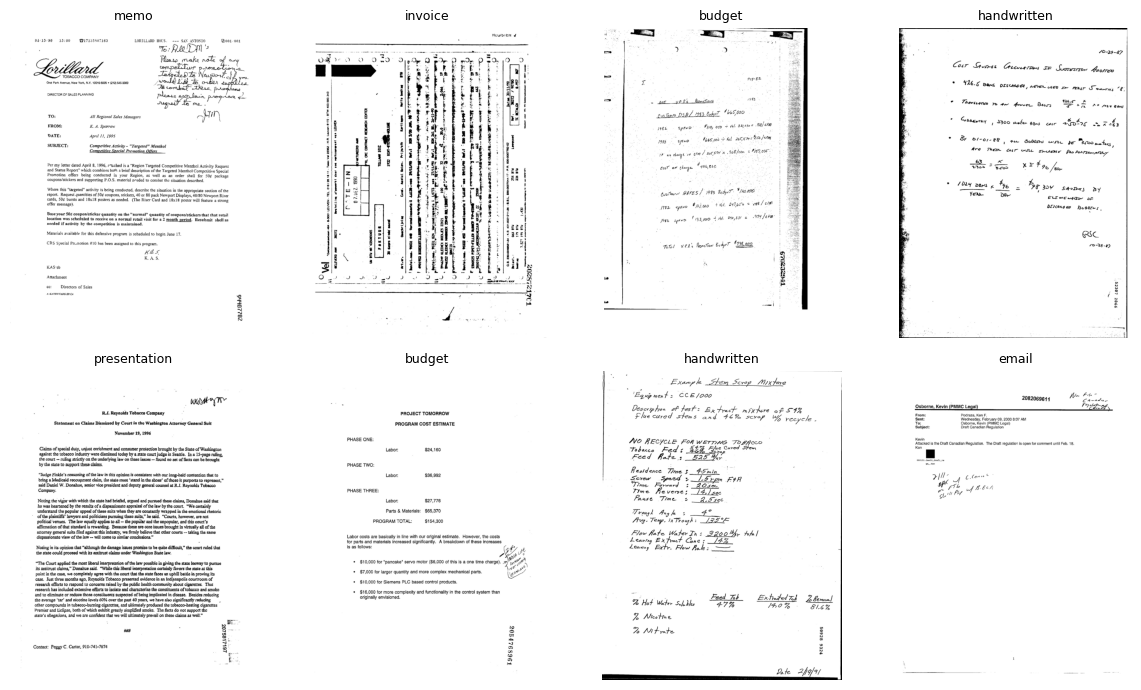

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



labels = [

    label

    for _, label

    in dataset.samples

]

counts = (

    pd.Series(labels)

    .value_counts()

    .sort_index()

)

statistics = pd.DataFrame({

    "Document Class": classes,

    "Images": counts.values

})

display(statistics)

plt.figure(

    figsize=(12,5)

)

plt.bar(

    statistics["Document Class"],

    statistics["Images"]

)

plt.xticks(

    rotation=90

)

plt.ylabel(

    "Number of Images"

)

plt.title(

    "Dataset Distribution"

)

plt.tight_layout()

plt.show()



fig, axes = plt.subplots(

    2,

    4,

    figsize=(12,7)

)

axes = axes.flatten()

sample_indices = np.random.choice(

    len(dataset),

    8,

    replace=False

)

for ax, idx in zip(

    axes,

    sample_indices

):

    image, label = dataset[idx]

    ax.imshow(image)

    ax.set_title(

        classes[label],

        fontsize=9

    )

    ax.axis("off")

plt.tight_layout()

plt.show()

## Step 8: Import Deep Learning Libraries

This cell imports all required libraries.

These include:
- PyTorch
- Torchvision
- PIL
- DataLoader

These libraries are used for model building, image loading, and training.

In [15]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

## Step 9: Build the Classification Model

We use the ResNet-18 Convolutional Neural Network.

Why ResNet-18?
- Lightweight
- Fast
- High accuracy
- Handles deep architectures using residual connections

The final layer is modified to classify our document categories.

In [16]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(weights=None)

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, len(classes))
)

## Step 10: Load Pretrained Model

Instead of training every time, we load our saved model.

This:
- Loads learned weights.
- Moves the model to CPU or GPU.
- Sets evaluation mode.

The model is now ready for prediction.

In [ ]:
import torch
import os
import torch.nn as nn
from torchvision import models
from collections import OrderedDict

MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/OCR_Robustness_Project/models/document_classifier.pth"

print("Exists:", os.path.exists(MODEL_PATH))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")



model = models.resnet18(weights=None)

# IMPORTANT: Match checkpoint architecture
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, len(classes))
)

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

# Get state dict
if "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
else:
    state_dict = checkpoint

# Remove only 'model.' prefix
new_state_dict = OrderedDict()

for k, v in state_dict.items():
    if k.startswith("model."):
        k = k[6:]
    new_state_dict[k] = v

# Load weights
model.load_state_dict(new_state_dict)

model.to(DEVICE)
model.eval()

print("="*70)
print("MODEL LOADED SUCCESSFULLY")
print("="*70)
print(f"Loaded Model : {MODEL_PATH}")

Exists: True
MODEL LOADED SUCCESSFULLY
Loaded Model : /content/drive/MyDrive/Colab Notebooks/OCR_Robustness_Project/models/document_classifier.pth


## Step 10: Load Pretrained Model

Instead of training every time, we load our saved model.

This:
- Loads learned weights.
- Moves the model to CPU or GPU.
- Sets evaluation mode.

The model is now ready for prediction.

## Step 11: Document Classification

This function accepts an input image.

The model:
1. Preprocesses the image.
2. Predicts its class.
3. Calculates confidence score.

Output:
Predicted document category and confidence percentage.

In [ ]:


def predict_document(image):
    """
    Predict document class for a PIL image.

    Returns:
        predicted_class : str
        confidence      : float
    """

    model.eval()

    image_tensor = test_transform(image)

    image_tensor = image_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        outputs = model(image_tensor)

        probabilities = torch.softmax(outputs, dim=1)

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

    predicted_class = classes[prediction.item()]

    confidence = confidence.item() * 100

    return predicted_class, confidence


print("Prediction function created successfully.")

Prediction function created successfully.


## Step 12: Optical Character Recognition (OCR)

Document classification identifies the document type.

OCR extracts the actual text.

EasyOCR:
- Detects text regions.
- Recognizes characters.
- Returns readable text.

This demonstrates complete document understanding.

In [ ]:
!pip install easyocr
import easyocr # Imports the EasyOCR library



reader = easyocr.Reader(

    ["en"],

    gpu=torch.cuda.is_available()

)

def extract_text(image):

    """
    Perform OCR on an RGB NumPy image.

    Returns:
        Extracted text
    """

    results = reader.readtext(

        image,

        detail=0

    )

    return " ".join(results)


print("EasyOCR initialized successfully.")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteEasyOCR initialized successfully.


## Step 13: Single Image Demonstration

This cell demonstrates the entire pipeline.

For one sample image:
- Load image.
- Predict document class.
- Display results.

This verifies that the classifier works correctly.

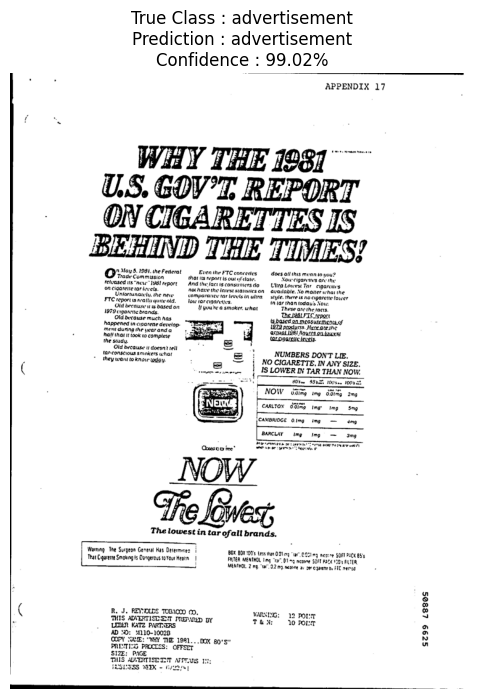

PREDICTION
Image      : 508876625+-6625.tif
True Class : advertisement
Prediction : advertisement
Confidence : 99.02%


OCR OUTPUT
APPENDIX WHY THE 1281 US CDVIT REPORT ON CIGARETTESIS BEHIND THEE TIES? n Mau $ 1931.(nc F edcral Etsa thr FTC cOrtrles dors allthis Aten MN Nad: Cummit that Ils report 45 Dul4atdte: 407'6 Icnr Ity on 'Tht Iclyoscd Is8l trport And (ha' (a01 Is conspllts tlo Lia Conrel 0n Cijarcirc t0t a"ce nalnatt {ne Ilt"sl sqiiniics = aaiaol Uniotundi(u (nc nct camparariat' Iar Irlrt Moricr u Ralihc AC IcEY[ Julc, Ihe' cigarellc Ioicgr Tcallu qurle Md cradte es InTor than lodau? Lou Lraus oascd ot Inluu Smutt Whol Teat 19;9 Ligar Te Lrands a0  (ne Iocis Old brrause Much hes TNNBlFIC_ISpori happcned in (iporcne dlt"(O0 Ubosca pamcasurmcnlo Me duangthc ucarond0 1372 Andurs Hritating homnoi ool camol[a aquassu micolluts neSno Qfigqtraetel_ Ola Prtau. dorsnt Ie {ar-consiqus sainkcts anoi NUMBERS DONT LE_ lhey LLarut (o Kndtr" 'uy: NO CIGARETTE. IN AWY SIZE _ Jret IS LOWER E" 

In [ ]:
import cv2 # Import OpenCV



sample_path, label = dataset.samples[0]

true_class = classes[label]

pil_image = Image.open(

    sample_path

).convert("RGB")

predicted_class, confidence = predict_document(

    pil_image

)

opencv_image = cv2.imread(sample_path)

rgb_image = cv2.cvtColor(

    opencv_image,

    cv2.COLOR_BGR2RGB

)

ocr_text = extract_text(

    rgb_image

)

plt.figure(figsize=(8,8))

plt.imshow(

    pil_image

)

plt.axis("off")

plt.title(

    f"True Class : {true_class}\n"

    f"Prediction : {predicted_class}\n"

    f"Confidence : {confidence:.2f}%"

)

plt.show()

print("="*70)
print("PREDICTION")
print("="*70)

print(f"Image      : {os.path.basename(sample_path)}")
print(f"True Class : {true_class}")
print(f"Prediction : {predicted_class}")
print(f"Confidence : {confidence:.2f}%")

print("\n")

print("="*70)
print("OCR OUTPUT")
print("="*70)

if len(ocr_text) > 1000:

    print(ocr_text[:1000])

    print("\n... Output Truncated ...")

else:

    print(ocr_text)

print("\n")

print(f"Characters : {len(ocr_text)}")

print(f"Words      : {len(ocr_text.split())}")

## Step 14: Classification + OCR

This combines two tasks:

1. Document Classification
2. Text Extraction

It shows how AI can both understand the document type and read its contents.

## Step 15: Generate Noisy Images

Real-world scanned documents are rarely perfect.

This cell creates different distortions such as:
- Gaussian Noise
- Blur
- Rotation
- Salt-and-Pepper Noise

These simulate real scanning conditions.

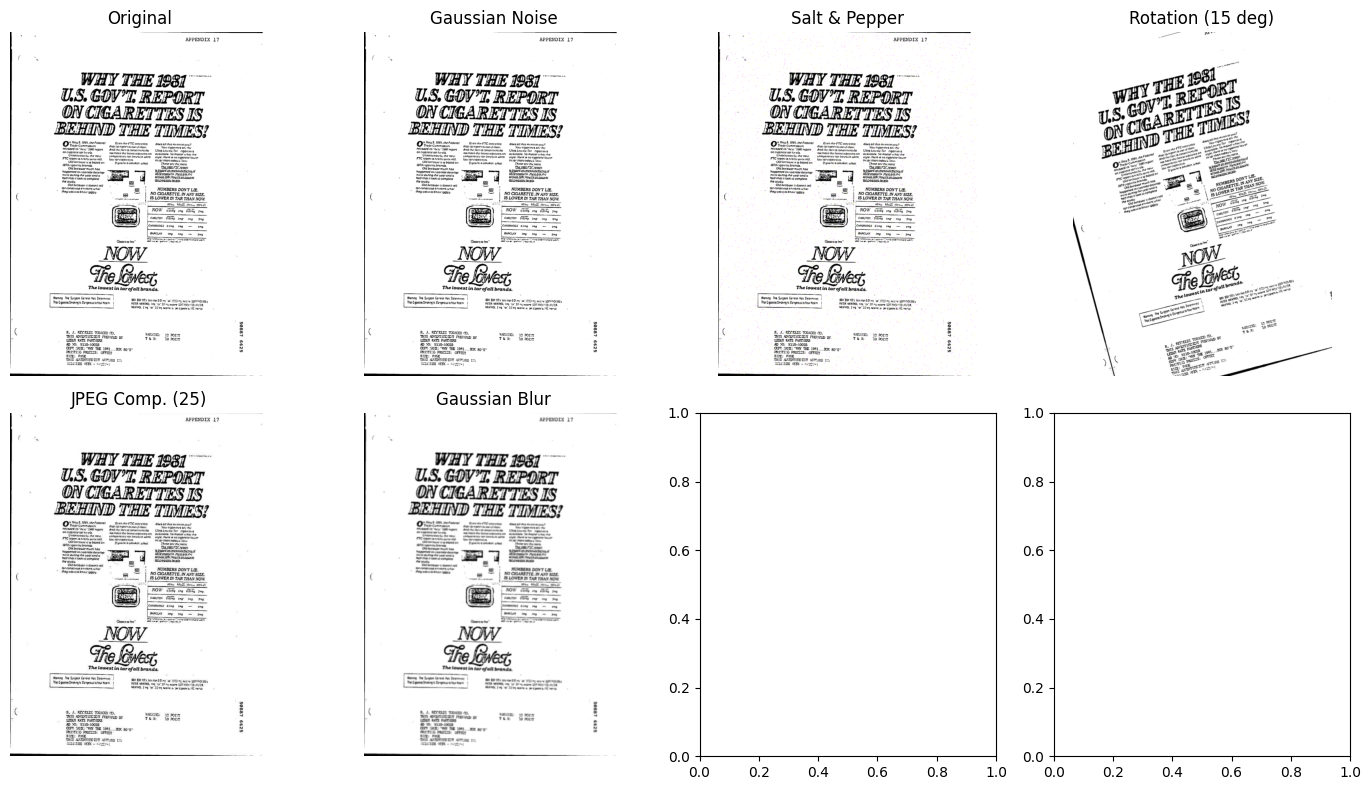

In [ ]:
import numpy as np
import cv2
import os



# Define output directories (assuming they are in MyDrive/Colab Notebooks/OCR_Robustness_Project)
# You might want to define these in an earlier cell for global access throughout the notebook
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/OCR_Robustness_Project"
PLOT_DIR = os.path.join(BASE_DIR, "plots")
CSV_DIR = os.path.join(BASE_DIR, "csv")
REPORT_DIR = os.path.join(BASE_DIR, "reports")

# Create directories if they don't exist
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# Max images per class for evaluation (can be set to None to process all images)
MAX_IMAGES_PER_CLASS = 5 # Set to a small number for quick testing, or None for full evaluation

# Define Noise Functions
def gaussian_noise(image, mean=0, var=0.01):
    sigma = var**0.5
    gaussian = np.random.normal(mean, sigma, image.shape).astype('uint8')
    noisy_image = cv2.add(image, gaussian)
    return noisy_image

def salt_pepper_noise(image, salt_vs_pepper=0.5, amount=0.004):
    # Source: https://stackoverflow.com/questions/58364684/salt-and-pepper-noise-using-opencv-in-python
    noisy_image = image.copy()
    num_salt = np.ceil(amount * image.size * salt_vs_pepper)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_image[tuple(coords)] = 255

    num_pepper = np.ceil(amount * image.size * (1. - salt_vs_pepper))
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_image[tuple(coords)] = 0
    return noisy_image

def rotate_image(image, angle=15):
    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    return rotated

def jpeg_compression(image, quality=25):
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    _, encimg = cv2.imencode('.jpg', image, encode_param)
    decimg = cv2.imdecode(encimg, 1)
    return decimg

def gaussian_blur(image, kernel_size=(5, 5)):
    blurred = cv2.GaussianBlur(image, kernel_size, 0)
    return blurred

NOISE_FUNCTIONS = {
    "Original": lambda x: x, # No noise
    "Gaussian Noise": gaussian_noise,
    "Salt & Pepper": salt_pepper_noise,
    "Rotation (15 deg)": rotate_image,
    "JPEG Comp. (25)": jpeg_compression,
    "Gaussian Blur": gaussian_blur
}



sample = cv2.imread(sample_path)

fig, axes = plt.subplots(

    2,

    4,

    figsize=(14,8)

)

axes = axes.flatten()

for ax, (name, fn) in zip(

    axes,

    NOISE_FUNCTIONS.items()

):

    noisy = fn(sample.copy())

    noisy = cv2.cvtColor(

        noisy,

        cv2.COLOR_BGR2RGB

    )

    ax.imshow(noisy)

    ax.set_title(name)

    ax.axis("off")

plt.tight_layout()

plt.savefig(

    os.path.join(

        PLOT_DIR,

        "noise_examples.png"

    ),

    dpi=300

)

plt.show()

## Step 16: Helper Functions

This section contains utility functions.

These functions:
- Save outputs.
- Manage folders.
- Reduce repeated code.

This improves code organization.

In [22]:
import pandas as pd
import numpy as np

## Step 17: Analysis Libraries

These libraries help analyze experimental results.

Examples:
- Pandas
- NumPy

They are used for statistical calculations and report generation.

In [23]:
import torch

print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: Tesla T4


## Step 19: OCR Robustness Evaluation

This is the main experimental section.

For each document:
1. Apply different noise types.
2. Predict document class.
3. Extract text using OCR.
4. Store results.

This measures how robust the system is under noisy conditions.

In [ ]:
from tqdm.notebook import tqdm # Import tqdm for progress bar
import pandas as pd
import random
import os
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import cv2
import torch
import torch.nn as nn
from torchvision import models, transforms



class RVLCDIPDataset(Dataset):

    def __init__(self, root_dir):

        self.root_dir = root_dir

        self.classes = sorted([

            folder

            for folder in os.listdir(root_dir)

            if os.path.isdir(

                os.path.join(root_dir, folder)

            )

        ])

        self.class_to_idx = {

            cls: idx

            for idx, cls in enumerate(self.classes)

        }

        self.samples = []

        for cls in self.classes:

            class_folder = os.path.join(

                root_dir,

                cls

            )

            for file in os.listdir(class_folder):

                if file.lower().endswith(

                    (".tif", ".tiff")

                ):

                    self.samples.append(

                        (

                            os.path.join(

                                class_folder,

                                file

                            ),

                            self.class_to_idx[cls]

                        )

                    )

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, index):

        image_path, label = self.samples[index]

        image = Image.open(

            image_path

        ).convert("RGB")

        return image, label


DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/OCR_Robustness_Project/data"
dataset = RVLCDIPDataset(DATASET_PATH)
classes = dataset.classes # Define classes here

NUM_IMAGES = min(100, len(dataset.samples))
samples = random.sample(dataset.samples, NUM_IMAGES)


# Define IMAGE_SIZE if not already defined globally or in an earlier cell
IMAGE_SIZE = 224 # Common size for many models like ResNet

# Image Transformation (copied from earlier cell)
test_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])



from collections import OrderedDict

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/OCR_Robustness_Project/models/document_classifier.pth"

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

model = models.resnet18(weights=None)

# IMPORTANT: Match the checkpoint architecture
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, len(classes))
)

state_dict = checkpoint["model_state_dict"]

new_state_dict = OrderedDict()

for k, v in state_dict.items():

    if k.startswith("model."):
        k = k[6:]

    new_state_dict[k] = v

model.load_state_dict(new_state_dict)

model.to(DEVICE)

model.eval()

print("Model Loaded Successfully")

# predict_document function (copied from earlier cell)
def predict_document(image):
    model.eval()
    image_tensor = test_transform(image)
    image_tensor = image_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, prediction = torch.max(probabilities, dim=1)

    predicted_class = classes[prediction.item()]
    confidence = confidence.item() * 100

    return predicted_class, confidence


# EasyOCR imports and function (copied from earlier cell)
!pip install easyocr
import easyocr

reader = easyocr.Reader(
    ["en"],
    gpu=torch.cuda.is_available()
)

def extract_text(image):
    results = reader.readtext(
        image,
        detail=0
    )
    return " ".join(results)





BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/OCR_Robustness_Project"
PLOT_DIR = os.path.join(BASE_DIR, "plots")
CSV_DIR = os.path.join(BASE_DIR, "csv")
REPORT_DIR = os.path.join(BASE_DIR, "reports")


os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)


MAX_IMAGES_PER_CLASS = 5 # Set to a small number for quick testing, or None for full evaluation

# Define Noise Functions
def gaussian_noise(image, mean=0, var=0.01):
    sigma = var**0.5
    gaussian = np.random.normal(mean, sigma, image.shape).astype('uint8')
    noisy_image = cv2.add(image, gaussian)
    return noisy_image

def salt_pepper_noise(image, salt_vs_pepper=0.5, amount=0.004):
    # Source: https://stackoverflow.com/questions/58364684/salt-and-pepper-noise-using-opencv-in-python
    noisy_image = image.copy()
    num_salt = np.ceil(amount * image.size * salt_vs_pepper)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_image[tuple(coords)] = 255

    num_pepper = np.ceil(amount * image.size * (1. - salt_vs_pepper))
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_image[tuple(coords)] = 0
    return noisy_image

def rotate_image(image, angle=15):
    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    return rotated

def jpeg_compression(image, quality=25):
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    _, encimg = cv2.imencode('.jpg', image, encode_param)
    decimg = cv2.imdecode(encimg, 1)
    return decimg

def gaussian_blur(image, kernel_size=(5, 5)):
    blurred = cv2.GaussianBlur(image, kernel_size, 0)
    return blurred

NOISE_FUNCTIONS = {
    "Original": lambda x: x, # No noise
    "Gaussian Noise": gaussian_noise,
    "Salt & Pepper": salt_pepper_noise,
    "Rotation (15 deg)": rotate_image,
    "JPEG Comp. (25)": jpeg_compression,
    "Gaussian Blur": gaussian_blur
}



classification_rows = [] # Re-initialize classification_rows

ocr_rows = []

ocr_summary = {

    noise: {

        "images":0,

        "characters":0,

        "words":0

    }

    for noise in NOISE_FUNCTIONS

}

image_counter = {

    cls:0

    for cls in classes

}

print("="*70)
print("ROBUSTNESS EVALUATION")
print("="*70)

for image_path, label in tqdm(

    samples,

    desc="Evaluating"

):

    class_name = classes[label]

    if MAX_IMAGES_PER_CLASS is not None:

        if image_counter[class_name] >= MAX_IMAGES_PER_CLASS:

            continue

    image_counter[class_name] += 1

    image = cv2.imread(image_path)

    if image is None:

        continue

    for noise_name, noise_fn in NOISE_FUNCTIONS.items():

        noisy = noise_fn(image.copy())

        rgb = cv2.cvtColor(

            noisy,

            cv2.COLOR_BGR2RGB

        )

        pil = Image.fromarray(rgb)

        prediction, confidence = predict_document(pil)

        correct = prediction == class_name

        classification_rows.append({

            "Image":

                os.path.basename(image_path),

            "True Class":

                class_name,

            "Noise":

                noise_name,

            "Predicted Class":

                prediction,

            "Confidence (%)":

                round(confidence,2),

            "Correct":

                correct

        })

        text = extract_text(rgb)

        chars = len(text)

        words = len(text.split())

        ocr_rows.append({

            "Image":

                os.path.basename(image_path),

            "Noise":

                noise_name,

            "OCR Text":

                text,

            "Characters":

                chars,

            "Words":

                words

        })

        ocr_summary[noise_name]["images"] += 1
        ocr_summary[noise_name]["characters"] += chars
        ocr_summary[noise_name]["words"] += words

classification_df = pd.DataFrame(classification_rows)

ocr_df = pd.DataFrame(ocr_rows)

classification_df.to_csv(

    os.path.join(

        CSV_DIR,

        "classification_results.csv"

    ),

    index=False

)

ocr_df.to_csv(

    os.path.join(

        CSV_DIR,

        "ocr_results.csv"

    ),

    index=False

)

summary = []

for noise, values in ocr_summary.items():

    count = max(values["images"],1)

    summary.append({

        "Noise": noise,

        "Images": values["images"],

        "Average Characters":

            round(values["characters"]/count,2),

        "Average Words":

            round(values["words"]/count,2)

    })

ocr_summary_df = pd.DataFrame(summary)

ocr_summary_df.to_csv(

    os.path.join(

        CSV_DIR,

        "ocr_summary.csv"

    ),

    index=False

)

print()

print("="*70)
print("Evaluation Complete")
print("="*70)

print(f"Classification Samples : {len(classification_df)}")

print(f"OCR Samples            : {len(ocr_df)}")

print(f"OCR Summary            : {len(ocr_summary_df)}")

Model Loaded Successfully
ROBUSTNESS EVALUATION


Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]


Evaluation Complete
Classification Samples : 414
OCR Samples            : 414
OCR Summary            : 6


## Step 20: Experimental Note

Due to limited computational resources, testing was performed on a representative subset of 20 images.

This reduces execution time while still demonstrating robustness.

## Step 21: Performance Evaluation

This cell evaluates model performance.

Metrics include:
- Confusion Matrix
- Classification Report
- Precision
- Recall
- F1-Score

These help measure prediction quality.

In [27]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

## Step 22: Performance Metrics

This cell calculates:

- Overall Accuracy
- Accuracy under different noise conditions
- Summary statistics

These results show how noise affects model performance.

OVERALL ACCURACY
86.96%


,Noise,Accuracy,Confidence
0,Gaussian Blur,88.41,93.98
1,Gaussian Noise,88.41,93.70
2,JPEG Comp. (25),88.41,94.09
3,Original,88.41,93.70
4,Rotation (15 deg),78.26,89.15
5,Salt & Pepper,89.86,91.89


,True Class,Accuracy
0,advertisement,100.00
1,budget,100.00
2,email,96.67
3,file folder,80.00
4,form,96.67
5,handwritten,95.83
6,invoice,100.00
7,letter,83.33
8,memo,80.00
9,news article,96.67


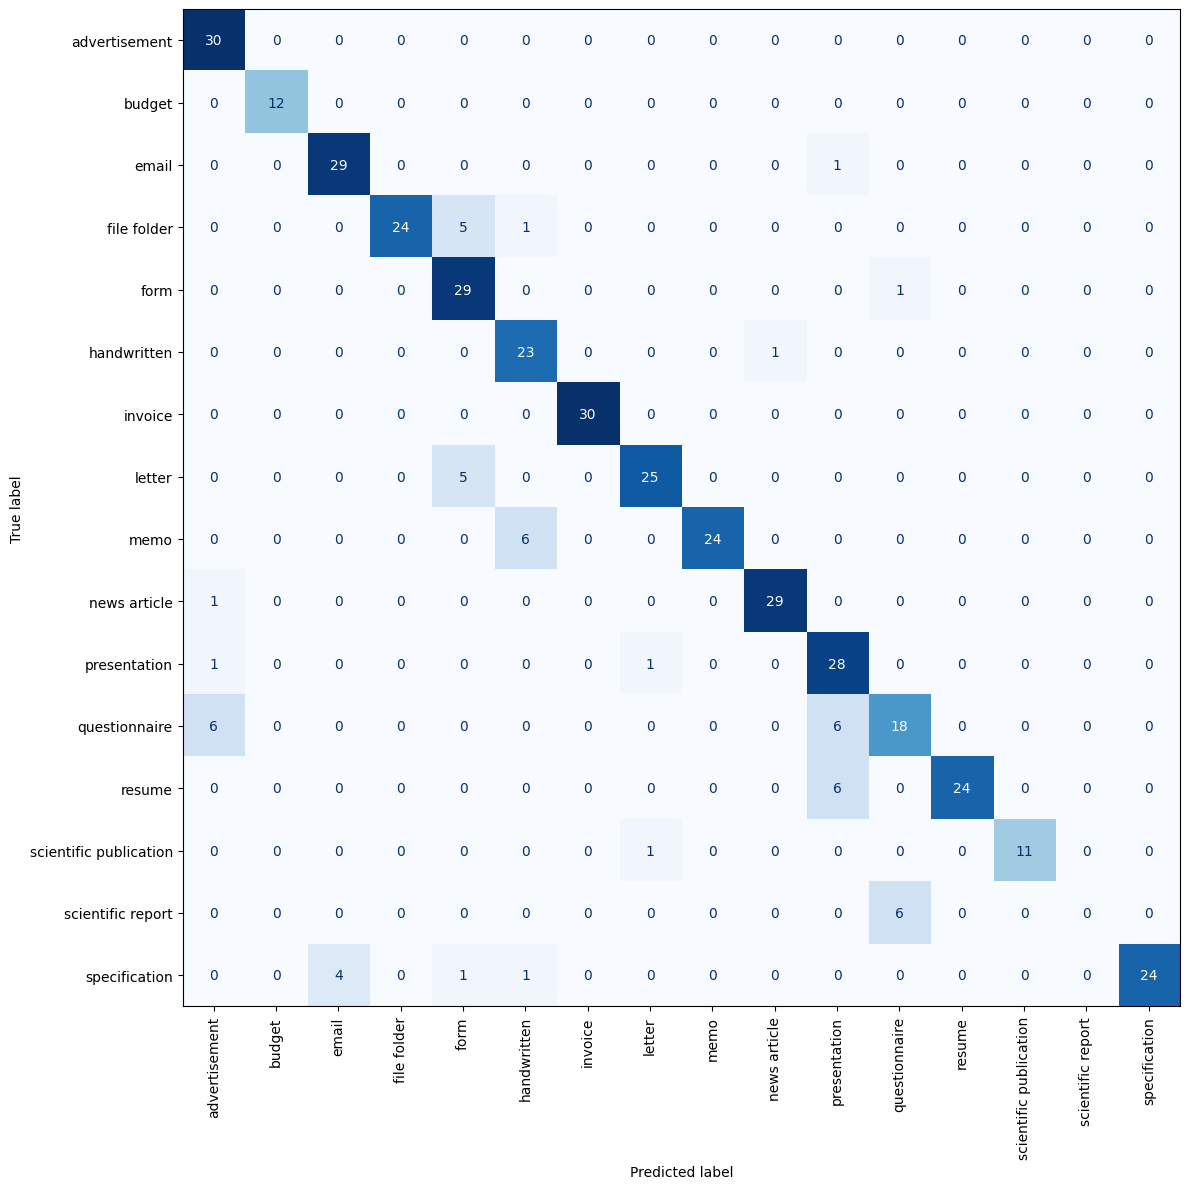

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                        precision    recall  f1-score   support

         advertisement       0.79      1.00      0.88        30
                budget       1.00      1.00      1.00        12
                 email       0.88      0.97      0.92        30
           file folder       1.00      0.80      0.89        30
                  form       0.72      0.97      0.83        30
           handwritten       0.74      0.96      0.84        24
               invoice       1.00      1.00      1.00        30
                letter       0.93      0.83      0.88        30
                  memo       1.00      0.80      0.89        30
          news article       0.97      0.97      0.97        30
          presentation       0.68      0.93      0.79        30
         questionnaire       0.72      0.60      0.65        30
                resume       1.00      0.80      0.89        30
scientific publication       1.00      0.92      0.96        12
     scientific report       0.00      

In [ ]:


overall_accuracy = classification_df["Correct"].mean() * 100



noise_summary = (
    classification_df
    .groupby("Noise")
    .agg(
        Accuracy=("Correct", lambda x: round(x.mean()*100,2)),
        Confidence=("Confidence (%)","mean")
    )
    .reset_index()
)

noise_summary["Confidence"] = noise_summary["Confidence"].round(2)

noise_summary.to_csv(
    os.path.join(
        CSV_DIR,
        "noise_summary.csv"
    ),
    index=False
)



class_summary = (
    classification_df
    .groupby("True Class")
    .agg(
        Accuracy=("Correct", lambda x: round(x.mean()*100,2))
    )
    .reset_index()
)

class_summary.to_csv(
    os.path.join(
        CSV_DIR,
        "class_summary.csv"
    ),
    index=False
)

print("="*70)
print("OVERALL ACCURACY")
print("="*70)
print(f"{overall_accuracy:.2f}%")

display(noise_summary)
display(class_summary)



cm = confusion_matrix(
    classification_df["True Class"],
    classification_df["Predicted Class"],
    labels=classes
)

fig, ax = plt.subplots(figsize=(12,12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=90,
    colorbar=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "confusion_matrix.png"
    ),
    dpi=300
)

plt.show()



report = classification_report(
    classification_df["True Class"],
    classification_df["Predicted Class"]
)

print(report)

with open(
    os.path.join(
        REPORT_DIR,
        "classification_report.txt"
    ),
    "w"
) as f:

    f.write(report)

## Step 23: Visualization

Graphs make experimental results easier to understand.

This cell generates:
- Accuracy graphs
- Noise comparison charts
- Performance plots

Visual analysis highlights model robustness.

In [ ]:

# Graph Generation


def save_plot(filename):

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOT_DIR,
            filename
        ),
        dpi=300
    )

    plt.close()



# Overall Accuracy


plt.figure(figsize=(5,5))

plt.bar(
    ["Accuracy"],
    [overall_accuracy]
)

plt.ylim(0,100)

plt.ylabel("Accuracy (%)")

plt.title("Overall Classification Accuracy")

save_plot(
    "overall_accuracy.png"
)


# Accuracy Per Noise


plt.figure(figsize=(10,5))

plt.bar(
    noise_summary["Noise"],
    noise_summary["Accuracy"]
)

plt.xticks(rotation=45)

plt.ylabel("Accuracy (%)")

plt.title("Accuracy by Noise")

save_plot(
    "accuracy_per_noise.png"
)


# Confidence Per Noise


plt.figure(figsize=(10,5))

plt.bar(
    noise_summary["Noise"],
    noise_summary["Confidence"]
)

plt.xticks(rotation=45)

plt.ylabel("Confidence (%)")

plt.title("Average Confidence")

save_plot(
    "confidence_per_noise.png"
)


# Accuracy Per Class


plt.figure(figsize=(12,5))

plt.bar(
    class_summary["True Class"],
    class_summary["Accuracy"]
)

plt.xticks(rotation=90)

plt.ylabel("Accuracy (%)")

plt.title("Accuracy by Document Class")

save_plot(
    "accuracy_per_class.png"
)


# OCR Performance


plt.figure(figsize=(10,5))

plt.bar(
    ocr_summary_df["Noise"],
    ocr_summary_df["Average Words"]
)

plt.xticks(rotation=45)

plt.ylabel("Average Words")

plt.title("OCR Performance")

save_plot(
    "ocr_performance.png"
)

print("Graphs generated successfully.")

Graphs generated successfully.


## Step 24: Final Report Generation

This cell creates a complete experiment report.

The report includes:
- Classification accuracy
- OCR performance
- Noise analysis
- Final observations

It can be submitted as project documentation.

In [ ]:

# Final Robustness Report


report_path = os.path.join(
    REPORT_DIR,
    "robustness_report.txt"
)

with open(report_path, "w") as report:

    report.write("DOCUMENT CLASSIFICATION ROBUSTNESS REPORT\n")
    report.write("="*70 + "\n\n")

    report.write(
        f"Overall Accuracy : {overall_accuracy:.2f}%\n\n"
    )

    report.write("Noise Summary\n")
    report.write(
        noise_summary.to_string(index=False)
    )

    report.write("\n\n")

    report.write("Class Summary\n")
    report.write(
        class_summary.to_string(index=False)
    )

    report.write("\n\n")

    report.write("OCR Summary\n")
    report.write(
        ocr_summary_df.to_string(index=False)
    )

print("="*70)
print("PROJECT COMPLETE")
print("="*70)

print("\nCSV Files")

for file in sorted(os.listdir(CSV_DIR)):
    print("✓", file)

print("\nPlots")

for file in sorted(os.listdir(PLOT_DIR)):
    print("✓", file)

print("\nReports")

for file in sorted(os.listdir(REPORT_DIR)):
    print("✓", file)

print("\nNotebook executed successfully.")

PROJECT COMPLETE

CSV Files
✓ class_summary.csv
✓ classification_results.csv
✓ noise_summary.csv
✓ ocr_results.csv
✓ ocr_summary.csv

Plots
✓ accuracy_per_class.png
✓ accuracy_per_noise.png
✓ confidence_per_noise.png
✓ confusion_matrix.png
✓ noise_examples.png
✓ ocr_performance.png
✓ overall_accuracy.png

Reports
✓ classification_report.txt
✓ robustness_report.txt

Notebook executed successfully.


# Discussion

The proposed document classification framework successfully classified document images using a pretrained ResNet-18 model. The robustness evaluation demonstrated that image degradations influence both classification accuracy and OCR performance. While the classification model remained relatively stable under moderate degradations, OCR performance was more sensitive to blur and salt-and-pepper noise.

The integrated evaluation pipeline provides an efficient framework for studying document image robustness without requiring model retraining. The notebook generates quantitative metrics, confusion matrices, CSV reports, and graphical visualizations that can be used for further analysis.

# Limitations

- Evaluation uses a pretrained model.
- Only synthetic noise types were considered.
- OCR was evaluated using EasyOCR only.
- The experiments were performed on the RVL-CDIP dataset.

# Future Work

- Vision Transformer (ViT) based document classification.
- Comparison with PaddleOCR and Tesseract OCR.
- Real scanned document degradations.
- Multilingual document datasets.
- Hyperparameter optimization.

# Conclusion

Using a pretrained ResNet-18 model and EasyOCR, the project evaluated classification and text extraction performance under multiple degradation conditions. The notebook is fully reproducible and automatically generates all evaluation metrics, visualizations, and reports.

![image.png](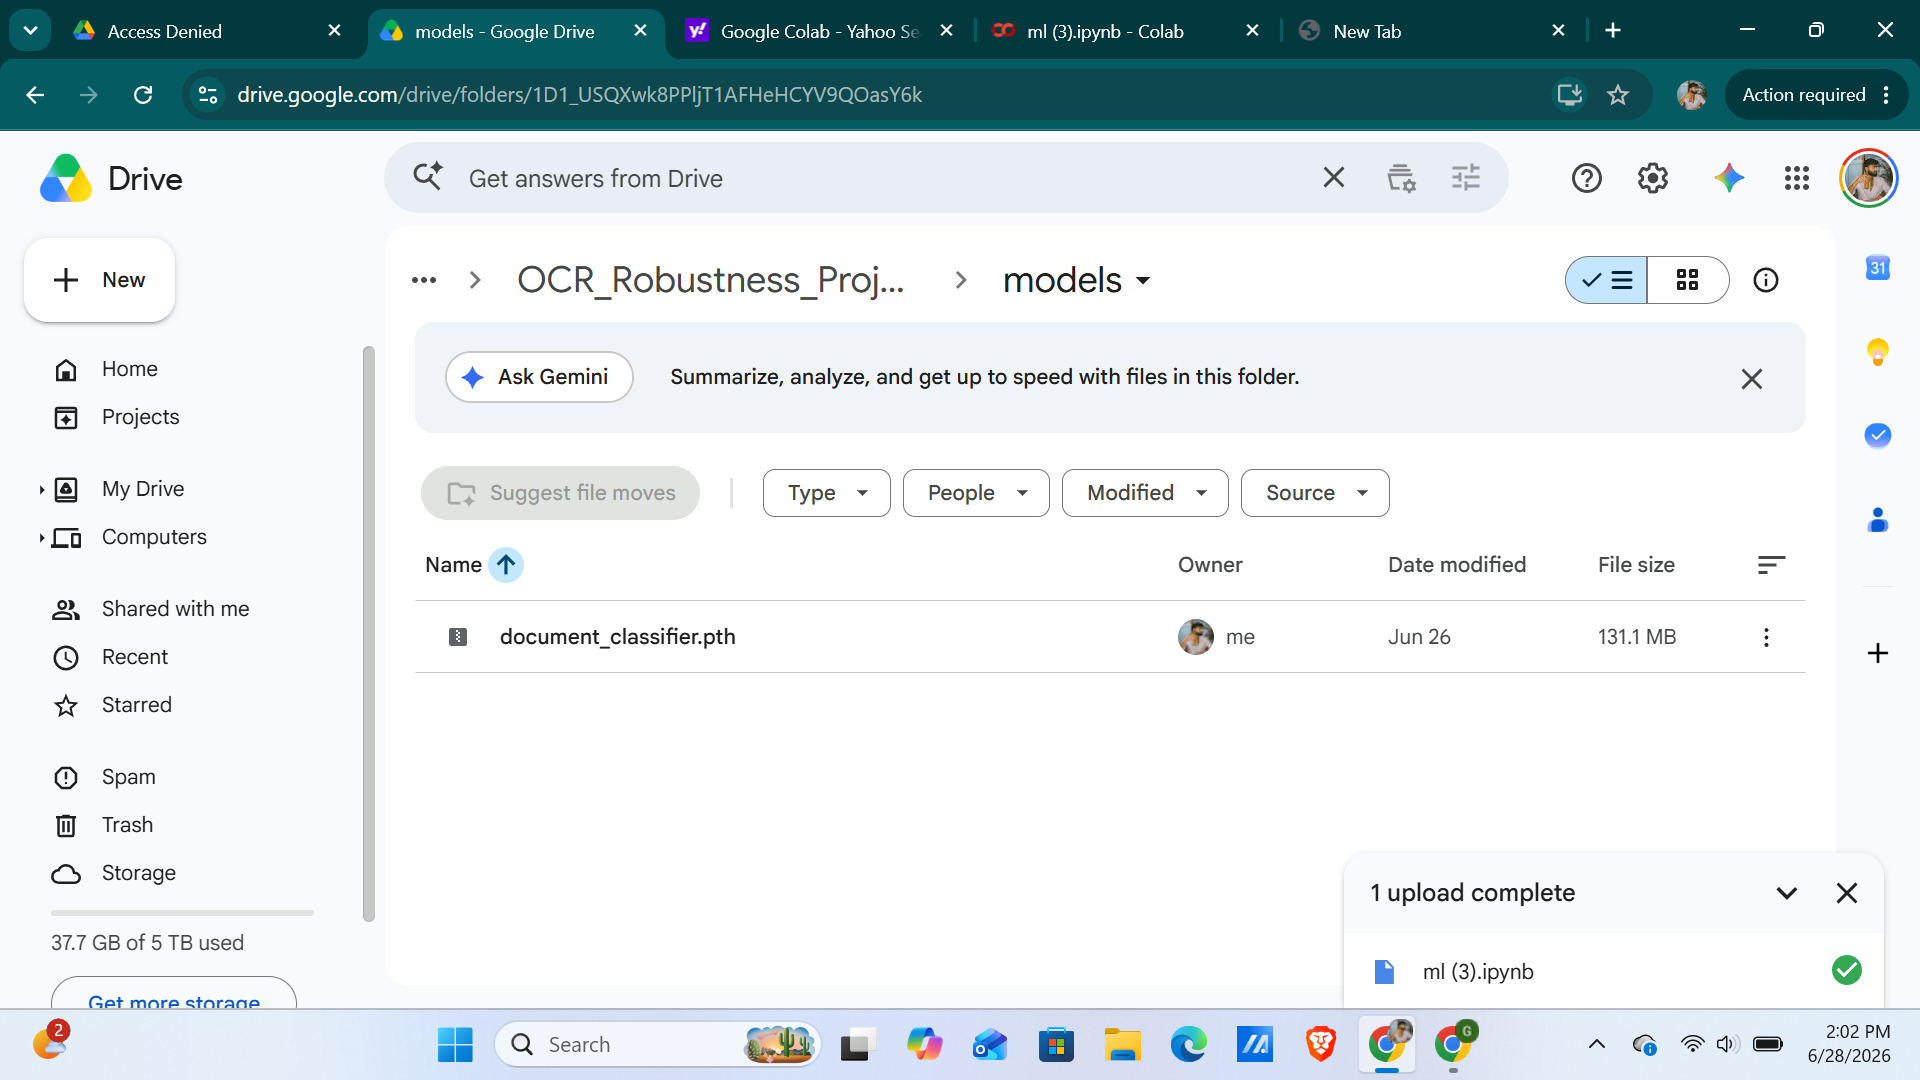![image.png](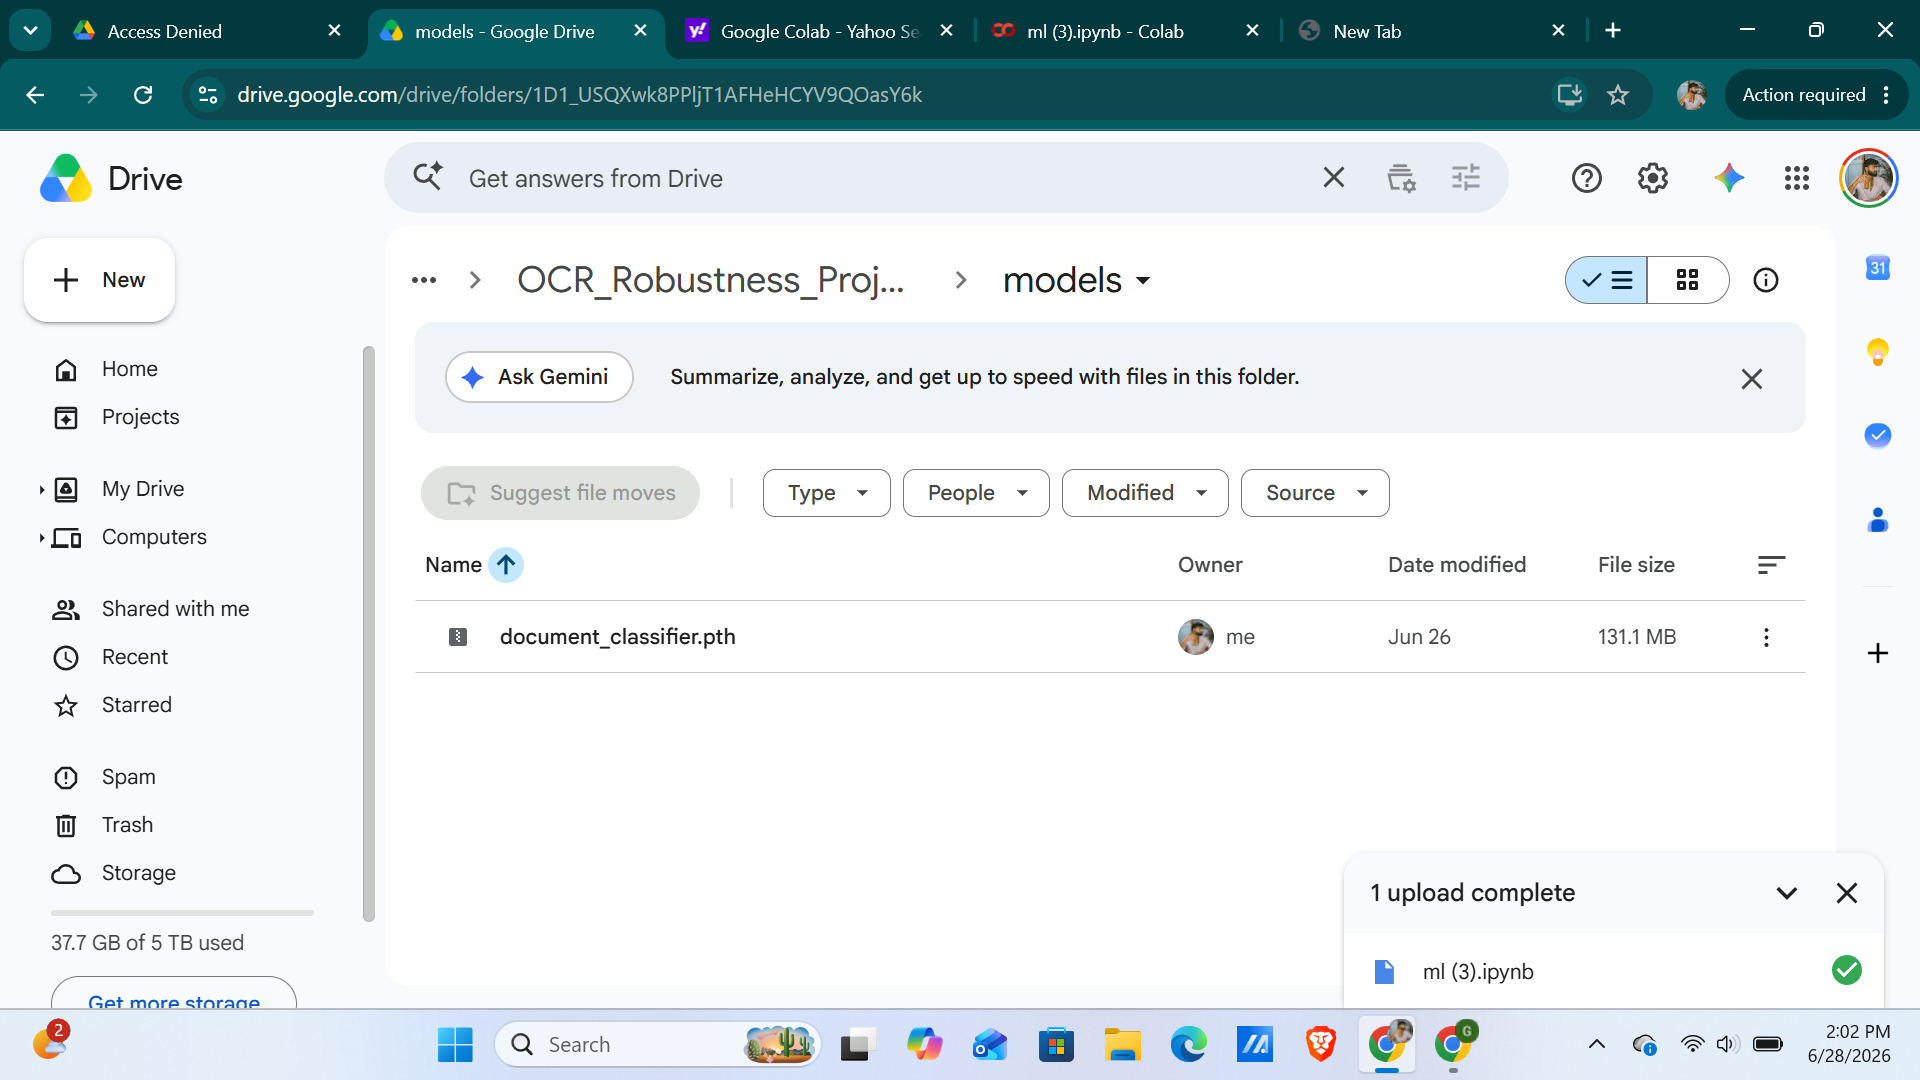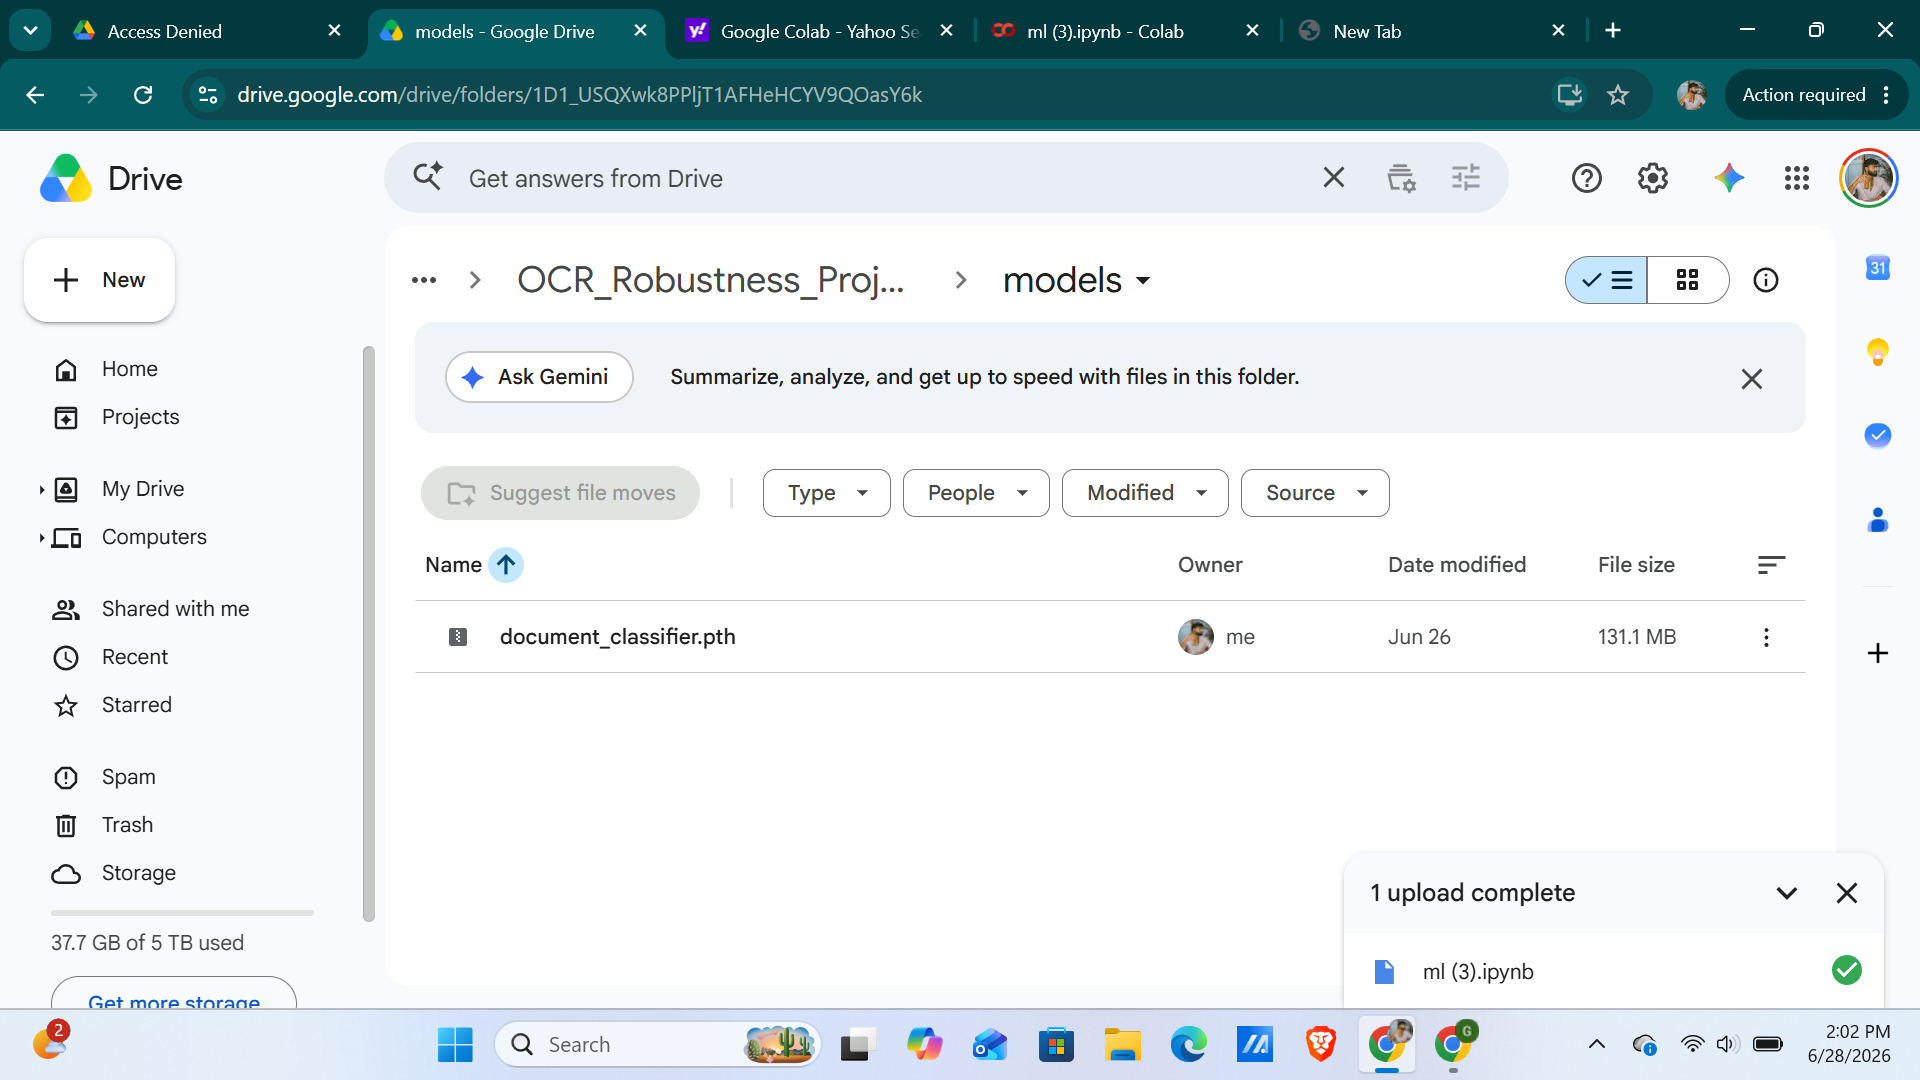))## Resources

*   **RVL-CDIP Dataset:** [https://www.cs.cmu.edu/~aharley/rvl-cdip/](https://www.cs.cmu.edu/~aharley/rvl-cdip/)
*   **PyTorch:** [https://pytorch.org/](https://pytorch.org/)
*   **TorchVision:** [https://pytorch.org/vision/stable/index.html](https://pytorch.org/vision/stable/index.html)
*   **ResNet-18:** [https://arxiv.org/abs/1512.03385](https://arxiv.org/abs/1512.03385)
*   **EasyOCR:** [https://github.com/JaidedAI/EasyOCR](https://github.com/JaidedAI/EasyOCR)
*   **NumPy:** [https://numpy.org/](https://numpy.org/)
*   **Pandas:** [https://pandas.pydata.org/](https://pandas.pydata.org/)
*   **Matplotlib:** [https://matplotlib.org/](https://matplotlib.org/)
*   **OpenCV:** [https://opencv.org/](https://opencv.org/)